# Maranatha.jl :: Load and Fit Workflow

This notebook demonstrates how to **load previously computed quadrature data**
and perform the **continuum extrapolation fit** separately.

This workflow is useful when:

- quadrature runs are expensive
- results are saved as `.jld2` files
- fitting and visualization are performed later

## Initialize environment

Set the Julia thread configuration and load the `Maranatha` package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha

## Define dataset location

Here we reconstruct the file name used by `run_Maranatha`.

The saved dataset contains:

- step sizes $h$
- quadrature estimates
- estimated errors
- rule and boundary information

These values will be used for the extrapolation fit.

In [2]:
bounds = (0.0, π)
ns = [2, 3, 4, 5, 6, 7, 8, 9]
save_path = :"."
result_string = "1D"
rule = :gauss_p4
boundary = :LU_EXEX
fit_terms = 4
nerr_terms = 2
ff_shift = 0
save_file = false

Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

"./result_1D_gauss_p4_LU_EXEX_N_2_3_4_5_6_7_8_9.jld2"

## Load quadrature dataset

The function `load_datapoint_results` reads the saved `.jld2` file
and reconstructs the quadrature dataset used for fitting.

In [3]:
run_result = load_datapoint_results(run_result_file)

(a = 0.0, b = 3.141592653589793, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.9999999998335218, 1.9999999999722913, 1.9999999999935836, 1.9999999999981353, 1.9999999999993598, 1.9999999999997509], err = [(ks = [8, 10, 12], coeffs = [1.1247885397696076e-9, 1.4753719807190856e-10, 3.815912407241898e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787326979e-8, -2.1194353746760364e-8, 1.3525608060985733e-9], total = 4.5644404932608e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099961932e-9, 5.72802215791421e-10, 5.0364674597346306e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.555169434377858e-9, -9.513043596006897e-10, 9.172718506234212e-11], total = 1.6955922598395105e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs = [2.249577

## Perform continuum extrapolation

Using the loaded quadrature results, we perform a weighted
least-$\chi^2$ fit to estimate the $h \to 0$ limit of the integral.

In [4]:
fit_result = least_chi_square_fit(
    run_result.a,
    run_result.b,
    run_result.h,
    run_result.avg,
    run_result.err,
    run_result.rule,
    run_result.boundary;
    nterms=fit_terms,
    ff_shift=ff_shift,
    nerr_terms=nerr_terms
)

[2026-03-07 19:12:48.739] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]


(estimate = 2.0, error_estimate = 5.296565967540264e-13, params = [2.0, -1.1263006603725685e-9, 5.704428238976156e-12, -4.532298529118268e-11], param_errors = [5.296565967540264e-13, 3.5538780346967413e-9, 8.013932182726316e-9, 3.8993097511263935e-9], cov = [2.805361104850573e-25 -1.2979787840518916e-21 2.6504196973627297e-21 -1.186784055281853e-21; -1.2979787840518901e-21 1.2630049085499972e-17 -2.795285709773992e-17 1.3121970219260564e-17; 2.6504196973627256e-21 -2.7952857097739924e-17 6.422310902933659e-17 -3.0857814691105806e-17; -1.1867840552818519e-21 1.3121970219260569e-17 -3.085781469110581e-17 1.5204616535229377e-17], powers = [0, 8, 9, 10], chisq = 1.3723638067958474e-6, redchisq = 3.4309095169896184e-7, dof = 4)

## Inspect fit result

Print the fitted parameters and the extrapolated integral value.

In [5]:
print_fit_result(fit_result)

[2026-03-07 19:12:50.605]            λ_0 = 2.00000000000000(53)
[2026-03-07 19:12:50.605]            λ_1 = -0.0000000011(36) *
[2026-03-07 19:12:50.605]            λ_2 = 0.0000000000(80) *
[2026-03-07 19:12:50.605]            λ_3 = -0.0000000000(39) *
[2026-03-07 19:12:50.605] 
[2026-03-07 19:12:50.605] Chi^2 / d.o.f. = 1.372363806796e-06 / 4 = 3.430909516990e-07
[2026-03-07 19:12:50.605] Result (h→0)   = 2.00000000000000(53)
[2026-03-07 19:12:50.605] 


## Plot convergence

Visualize the quadrature convergence and the extrapolation fit.

The plot displays:

- quadrature estimates
- estimated errors
- fitted continuum limit
- reference convergence behavior

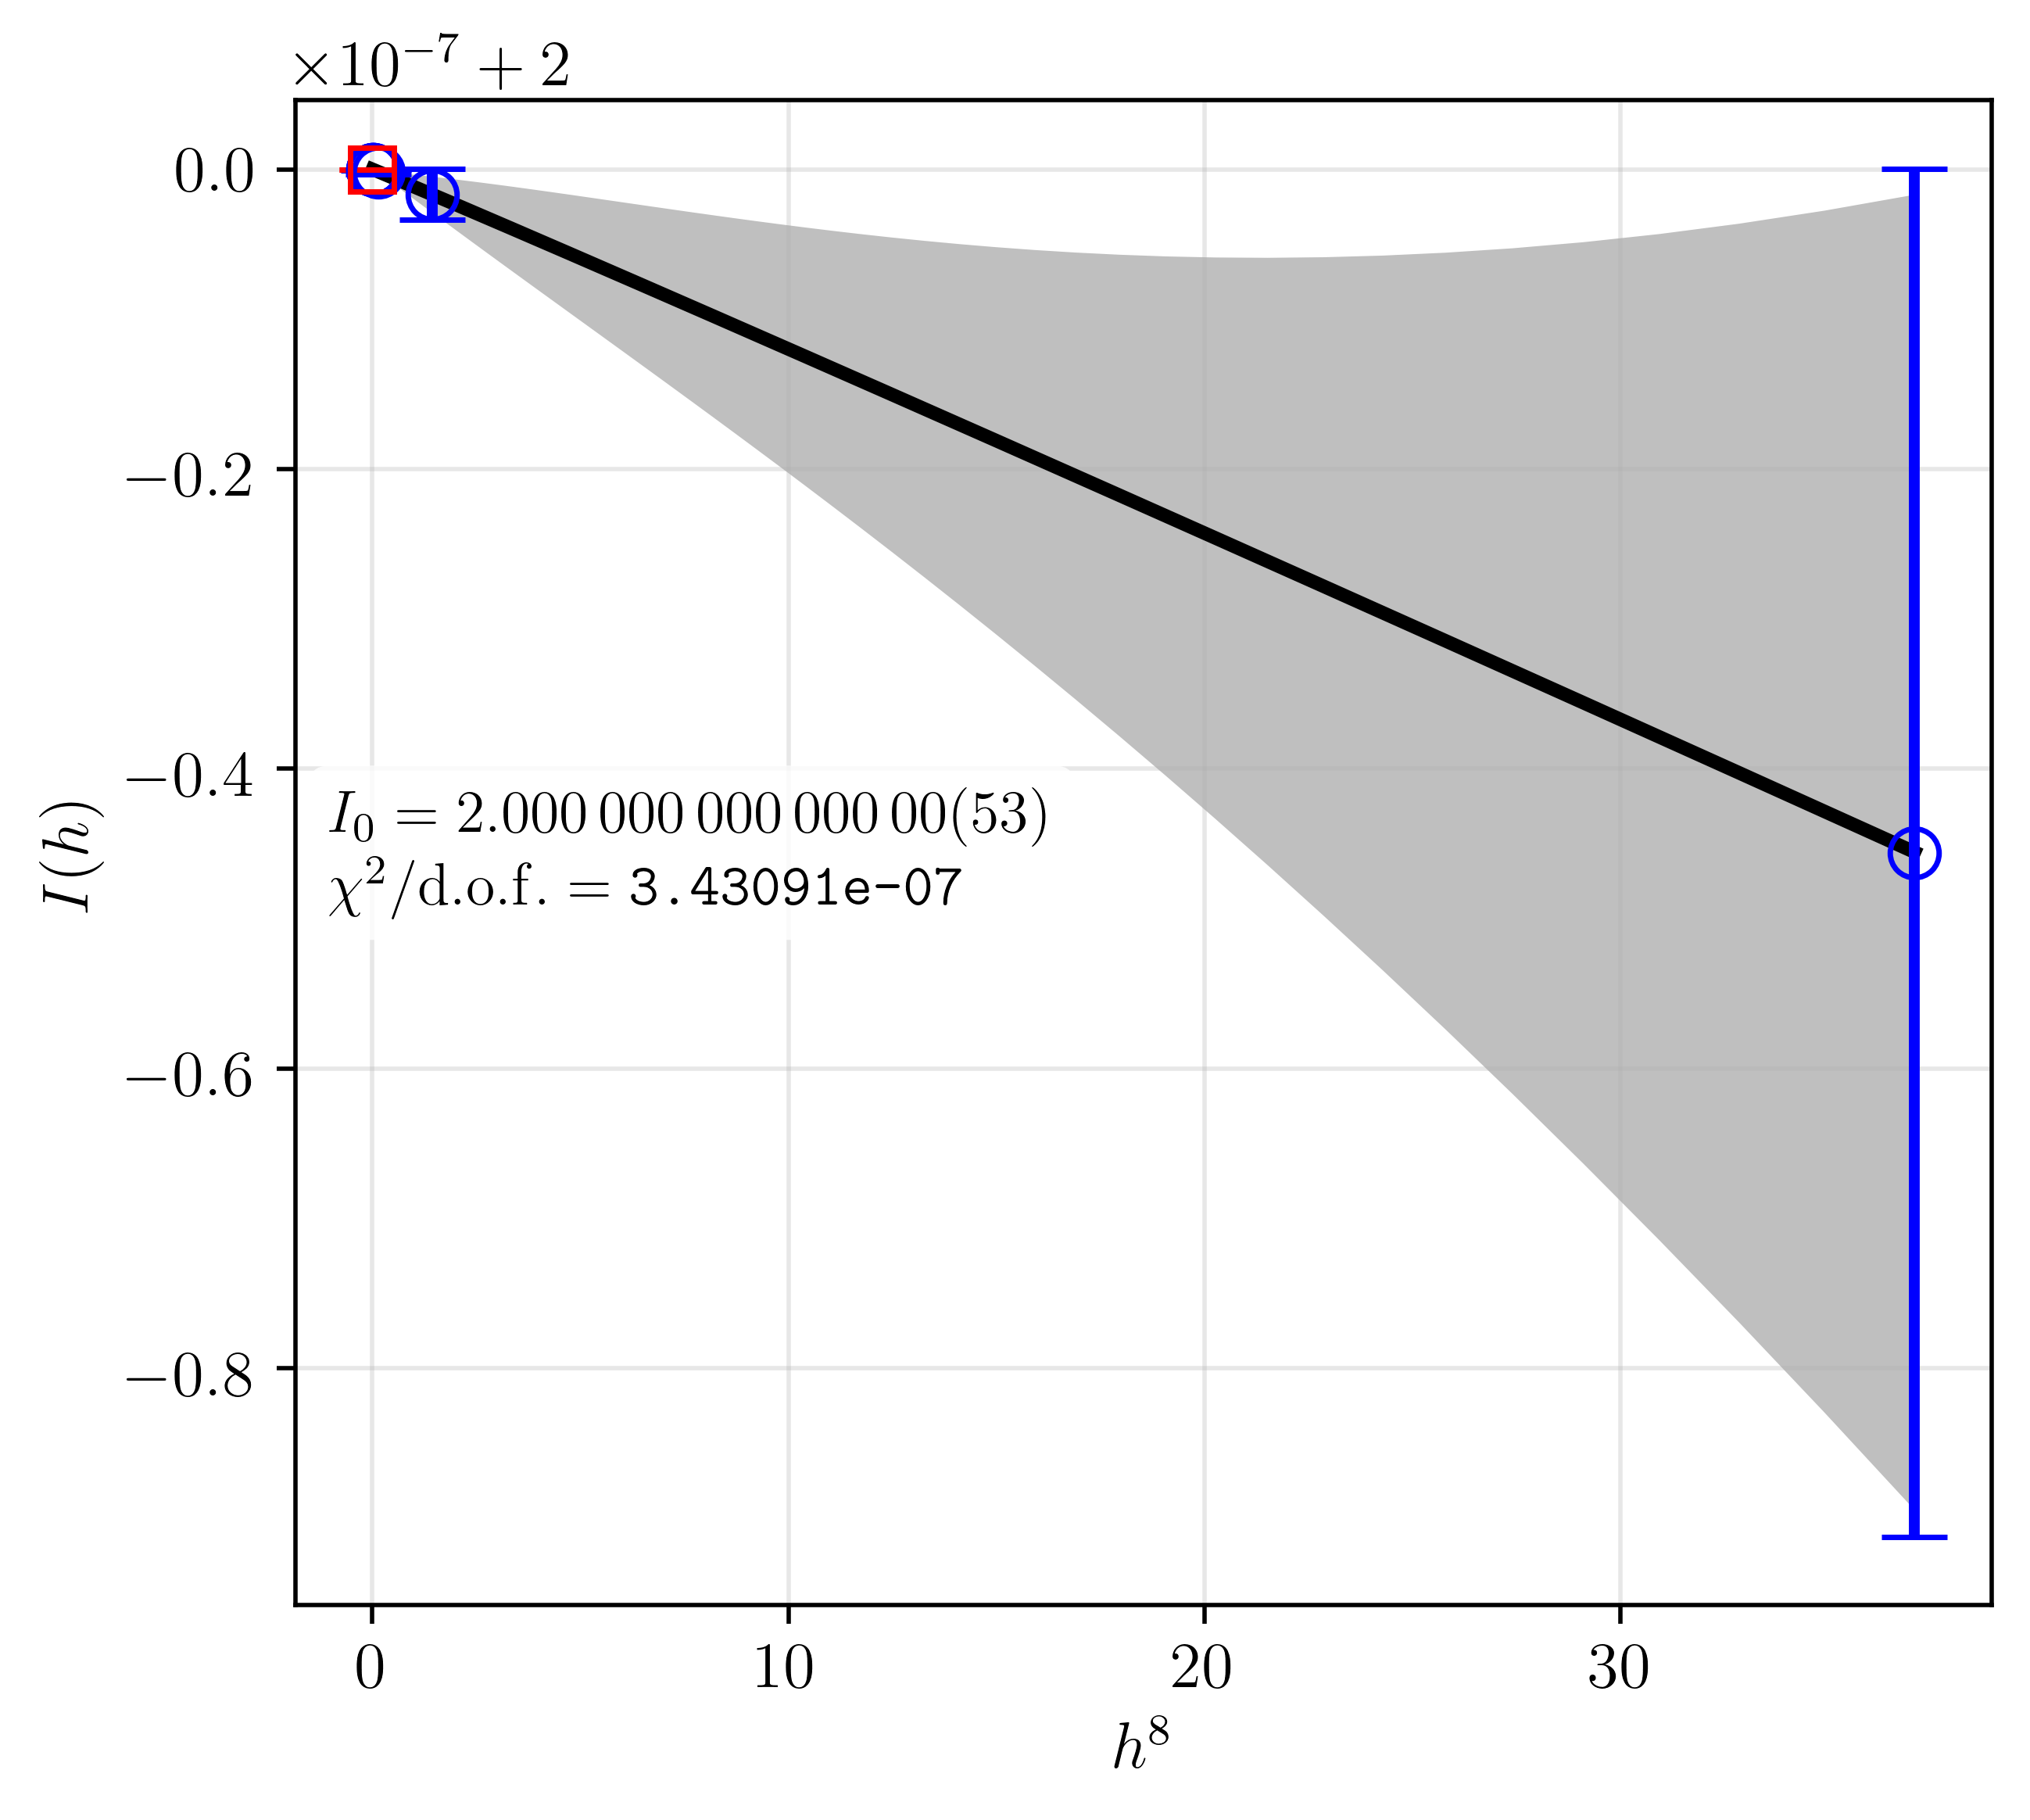

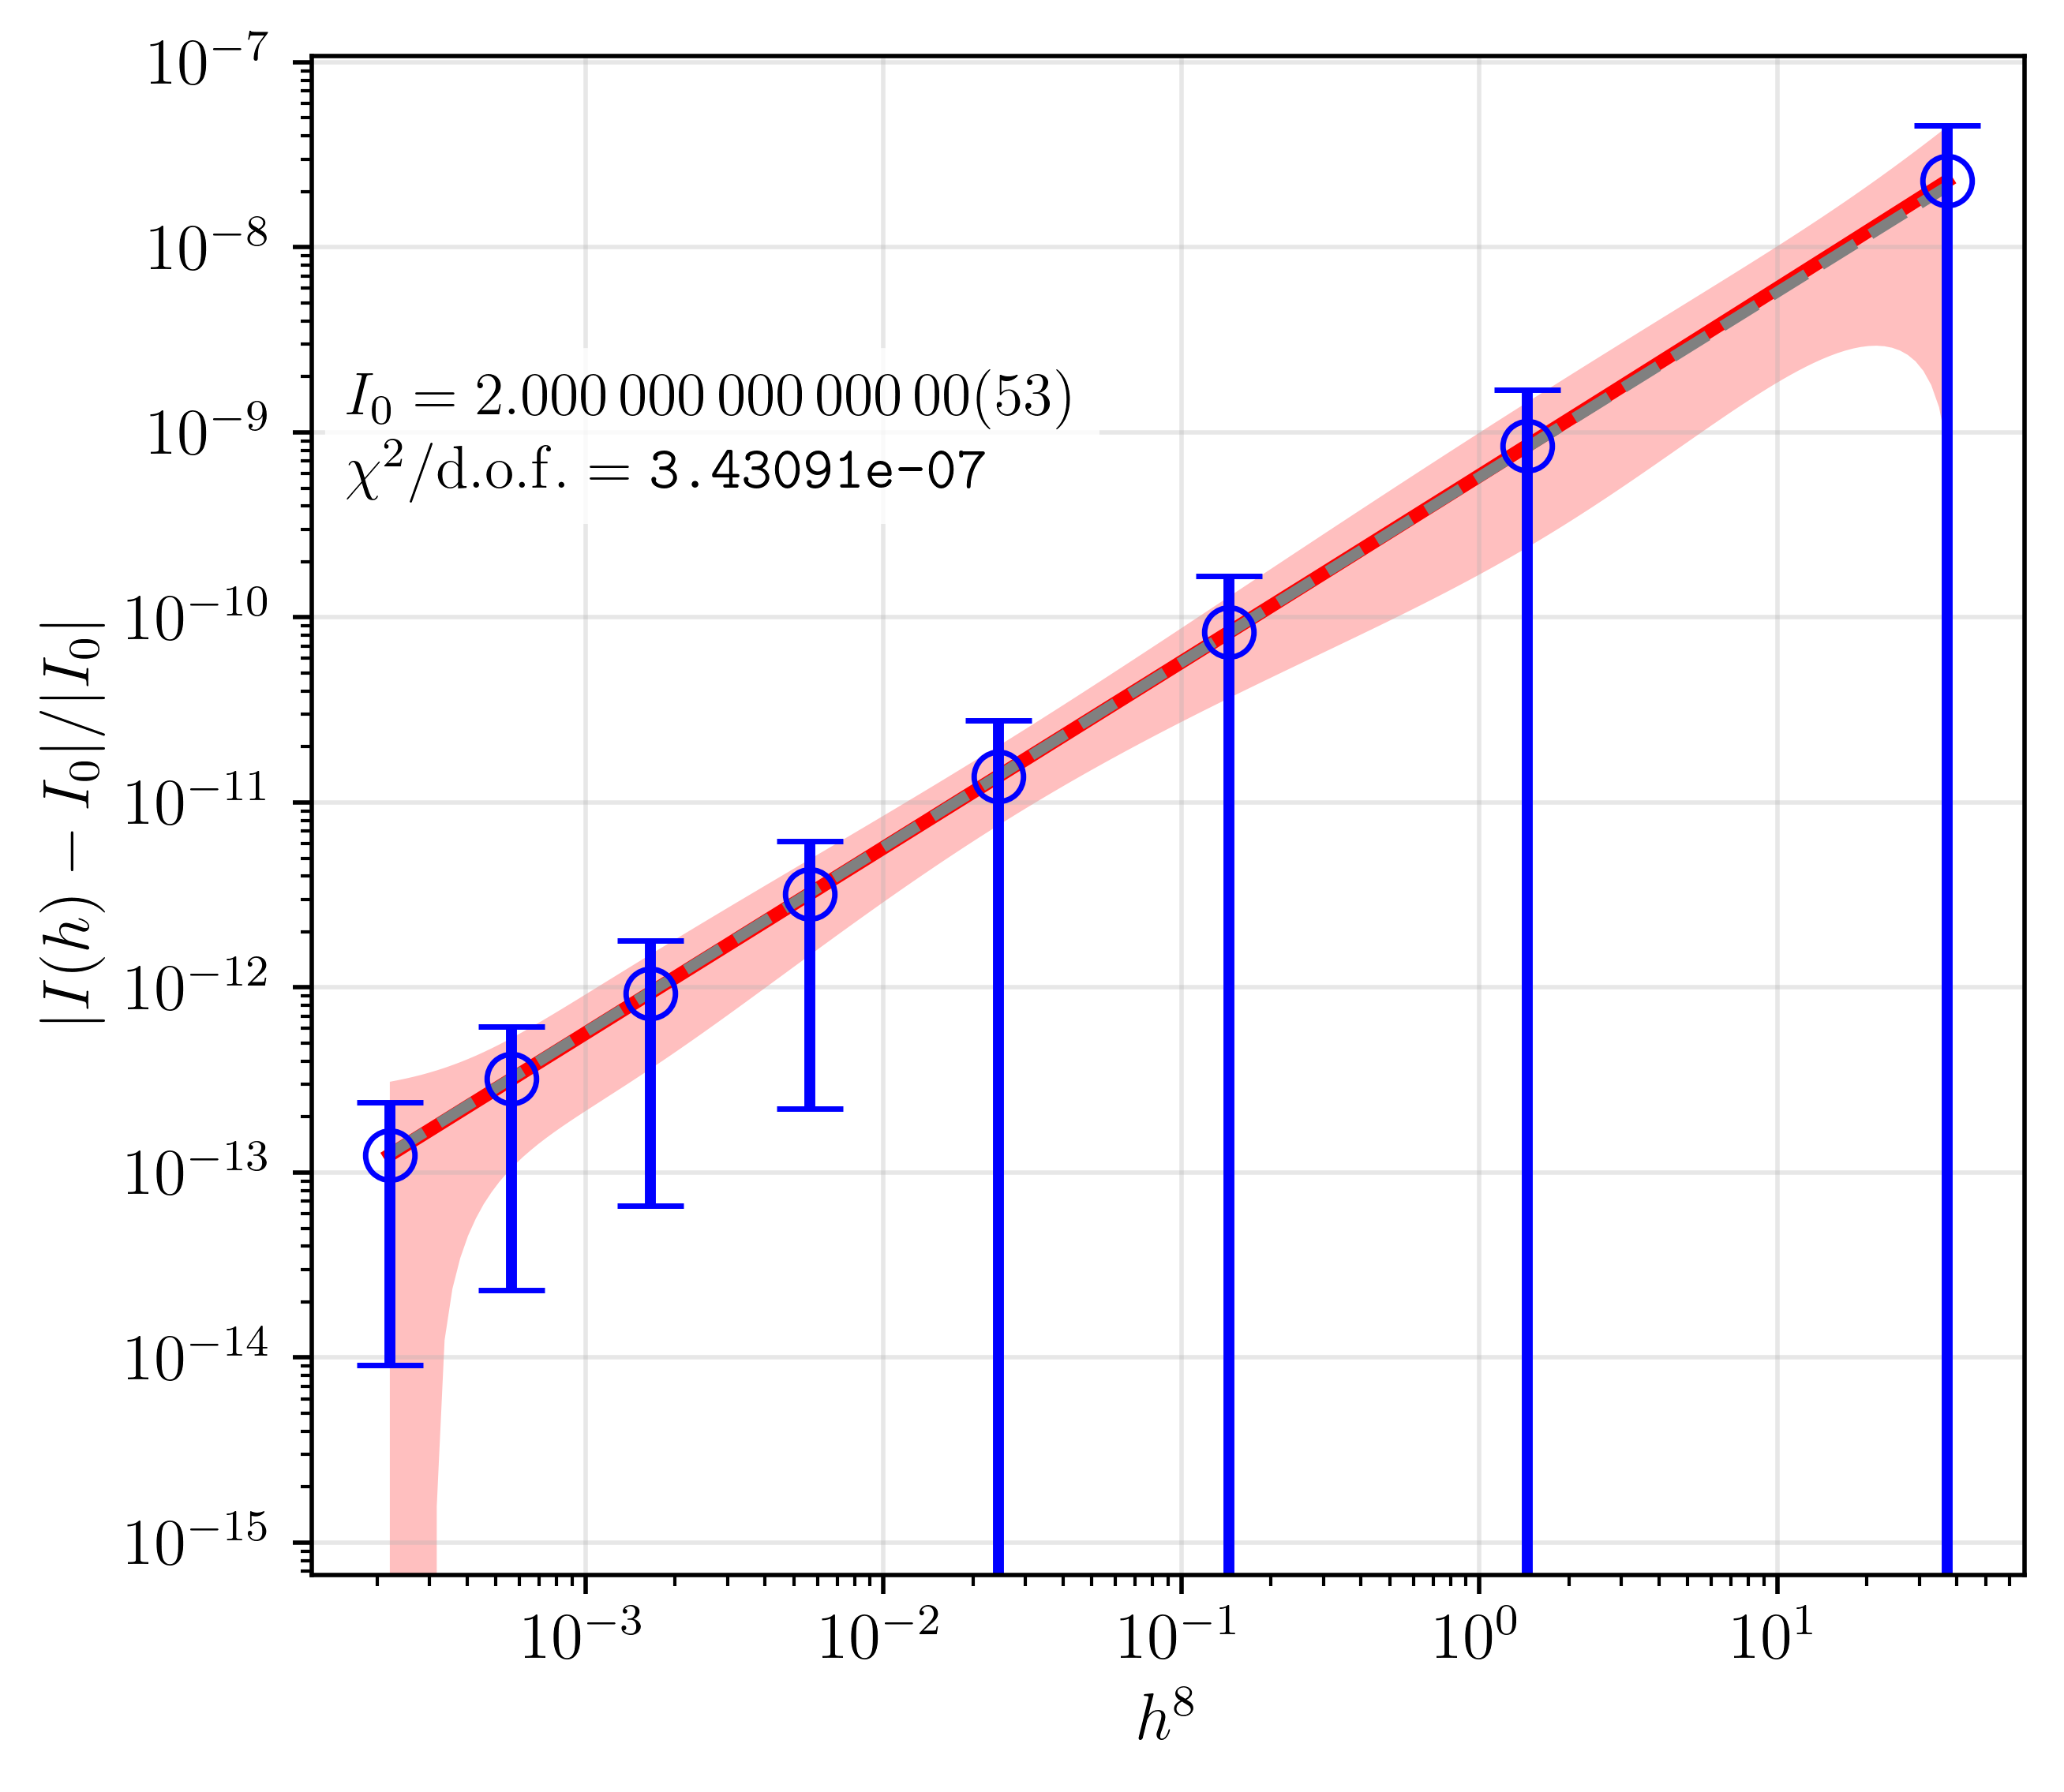

In [6]:
plot_convergence_result(
    bounds..., 
    result_string, 
    run_result.h, 
    run_result.avg, 
    run_result.err, 
    fit_result; 
    rule=rule, 
    boundary=boundary,
    save_file=save_file
)